In [1]:
import sys
import time
import os

import pandas as pd
import numpy as np
from datetime import datetime
from tqdm import tqdm
import json
import random
import re
from typing import Optional

import pymaid
import navis

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx
import matplotlib.cm as cm


In [203]:
# auth
path = 'D:/flywire_backup/cave/cat_client.json' # replace with your path

with open(path, 'r') as f:
    conn_file = json.load(f)
api_token = conn_file['api_token']
http_user = conn_file['http_user']
http_password = conn_file['http_password']
server = conn_file['server']

megalopta_client = pymaid.CatmaidInstance(server = server, 
                                api_token = api_token,
                                caching = True,
                                project_id = 8,
                                http_user = http_user,
                                http_password = http_password 
                                )
eciton_client = pymaid.CatmaidInstance(server = server, 
                                api_token = api_token,
                                caching = True,
                                project_id = 7,
                                http_user = http_user,
                                http_password = http_password 
                                )

INFO  : Global CATMAID instance set. Caching is ON. (pymaid)
INFO  : Global CATMAID instance set. Caching is ON. (pymaid)


### functions

In [194]:
def glom_input_summary(G):
    """
    Returns:
      glom_owner: {glom_node: tubu_node or None}  (only set if exactly 1 TUBU predecessor)
      multi_input_gloms: set(glom_nodes)          (if >1 TUBU predecessor)
      zero_input_gloms: set(glom_nodes)           (if 0 TUBU predecessor)
    """
    glom_owner = {}
    multi_input_gloms = set()
    zero_input_gloms = set()

    for n, d in G.nodes(data=True):
        if d.get("kind") != "GLOM":
            continue

        preds = list(G.predecessors(n))
        tubu_preds = [p for p in preds if G.nodes[p].get("kind") == "TUBU"]

        if len(tubu_preds) == 1:
            glom_owner[n] = tubu_preds[0]
        elif len(tubu_preds) == 0:
            glom_owner[n] = None
            zero_input_gloms.add(n)
        else:
            glom_owner[n] = None
            multi_input_gloms.add(n)

    return glom_owner, multi_input_gloms, zero_input_gloms

def glom_owner_map(G):
    """
    Returns {glom: tubu or None}
    """
    owner = {}
    for n, d in G.nodes(data=True):
        if d.get("kind") != "GLOM":
            continue
        preds = [p for p in G.predecessors(n) if G.nodes[p].get("kind") == "TUBU"]
        owner[n] = preds[0] if len(preds) == 1 else None
    return owner


def edge_colors_propagate(G, tubu_color, default_glom_edge="#969696"):
    """
    - TUBU->GLOM edges: TUBU color
    - GLOM->ER edges:
        * if glom has exactly 1 TUBU input: that TUBU color
        * else: black
    """
    glom_owner, multi_input_gloms, zero_input_gloms = glom_input_summary(G)

    ecolors = []
    for u, v in G.edges():
        uk = G.nodes[u].get("kind")
        vk = G.nodes[v].get("kind")

        if uk == "TUBU" and vk == "GLOM":
            ecolors.append(tubu_color.get(u, default_glom_edge))

        elif uk == "GLOM" and vk == "ER":
            owner = glom_owner.get(u, None)
            if owner is not None:
                ecolors.append(tubu_color.get(owner, "black"))
            else:
                # multi-input or zero-input: force black
                ecolors.append("black")

        else:
            # any unexpected edge types
            ecolors.append(default_glom_edge)

    return ecolors, multi_input_gloms, zero_input_gloms

def node_colors_propagate(G, tubu_color, glom_fallback="#bdbdbd"):
    """
    - TUBU: own color
    - GLOM: same color as its upstream TUBU (if unique)
    - ER: light neutral
    """
    glom_owner = glom_owner_map(G)

    colors = []
    for n, d in G.nodes(data=True):
        kind = d.get("kind")

        if kind == "TUBU":
            colors.append(tubu_color[n])

        elif kind == "GLOM":
            owner = glom_owner.get(n)
            if owner is not None:
                colors.append(tubu_color.get(owner, glom_fallback))
            else:
                colors.append(glom_fallback)

        else:  # ER
            colors.append("#f5f5f5")

    return colors


def layered_barycenter_layout(G, kind_order=("TUBU", "GLOM", "ER"),
                              layer_y=None, iters=20, seed=0):
    """
    Fixed y per layer, optimized x ordering within each layer to reduce crossings.
    Edges assumed to run TUBU->GLOM->ER, but works generally for 3 layers.
    """
    if layer_y is None:
        layer_y = {"TUBU": 2.0, "GLOM": 1.0, "ER": 0.0}

    rng = random.Random(seed)

    # Collect nodes by kind
    layers = {k: [n for n, d in G.nodes(data=True) if d.get("kind") == k] for k in kind_order}
    for k in layers:
        # start with stable-ish random to avoid alphabetical artifacts
        layers[k] = sorted(layers[k], key=str)
        rng.shuffle(layers[k])

    def x_positions(layer_nodes):
        if len(layer_nodes) <= 1:
            return {layer_nodes[0]: 0.5} if layer_nodes else {}
        return {n: i / (len(layer_nodes) - 1) for i, n in enumerate(layer_nodes)}

    # adjacency helpers (treat as undirected for ordering)
    nbrs = {n: set(G.predecessors(n)).union(set(G.successors(n))) for n in G.nodes()}

    # iterative sweeps
    for _ in range(iters):
        # top->bottom sweep (optimize GLOM using TUBU, then ER using GLOM)
        for li in range(1, len(kind_order)):
            upper = kind_order[li - 1]
            cur = kind_order[li]
            xpos_upper = x_positions(layers[upper])

            def bary(n):
                xs = [xpos_upper[m] for m in nbrs[n] if m in xpos_upper]
                return sum(xs) / len(xs) if xs else None

            keyed = []
            for n in layers[cur]:
                b = bary(n)
                keyed.append((1e9 if b is None else b, str(n), n))
            layers[cur] = [n for _, _, n in sorted(keyed)]

        # bottom->top sweep (optimize GLOM using ER, then TUBU using GLOM)
        for li in range(len(kind_order) - 2, -1, -1):
            lower = kind_order[li + 1]
            cur = kind_order[li]
            xpos_lower = x_positions(layers[lower])

            def bary(n):
                xs = [xpos_lower[m] for m in nbrs[n] if m in xpos_lower]
                return sum(xs) / len(xs) if xs else None

            keyed = []
            for n in layers[cur]:
                b = bary(n)
                keyed.append((1e9 if b is None else b, str(n), n))
            layers[cur] = [n for _, _, n in sorted(keyed)]

    # final positions
    pos = {}
    for k in kind_order:
        xpos = x_positions(layers[k])
        for n, x in xpos.items():
            pos[n] = (x, layer_y[k])

    return pos


def classify_from_name(name):
    """
    Robust to underscores and your naming scheme.
    Returns 'TUBU', 'ER', or None.
    """
    if not name:
        return None
    s = str(name)

    # ER names in your examples look like: ER_L_MBUv_63018 (start with ER)
    if re.match(r'^ER(?:[_\-\s]|$)', s):
        return "ER"

    # TUBU names look like: TUBU_MBUv_...
    if re.match(r'^TUBU(?:[_\-\s]|$)', s):
        return "TUBU"

    return None


def quantify_tubu_er(G):
    # collect nodes
    tubus = [n for n, d in G.nodes(data=True) if d.get("kind") == "TUBU"]
    gloms = [n for n, d in G.nodes(data=True) if d.get("kind") == "GLOM"]
    ers   = [n for n, d in G.nodes(data=True) if d.get("kind") == "ER"]

    # glom -> upstream tubus (can be 0,1,>1)
    glom_tubus = {}
    for g in gloms:
        preds = [p for p in G.predecessors(g) if G.nodes[p].get("kind") == "TUBU"]
        glom_tubus[g] = preds

    # glom -> downstream ERs
    glom_ers = {}
    for g in gloms:
        outs = [v for v in G.successors(g) if G.nodes[v].get("kind") == "ER"]
        glom_ers[g] = outs

    # effective edges: TUBU -> ER via glom (track also via how many gloms)
    tubu_to_er = {t: set() for t in tubus}
    tubu_to_er_glomcount = {}  # (t,e) -> #gloms connecting them

    for g in gloms:
        for t in glom_tubus[g]:
            for e in glom_ers[g]:
                tubu_to_er[t].add(e)
                tubu_to_er_glomcount[(t, e)] = tubu_to_er_glomcount.get((t, e), 0) + 1

    # ---------- Per-TUBU divergence table ----------
    rows_t = []
    for t in tubus:
        # gloms this tubu innervates (count gloms where t is a predecessor)
        t_gloms = [g for g in gloms if t in glom_tubus[g]]
        er_counts_per_glom = [len(glom_ers[g]) for g in t_gloms]

        rows_t.append({
            "TUBU": t,
            "gloms_used": len(t_gloms),
            "ER_out_unique": len(tubu_to_er.get(t, set())),
            "mean_ERs_per_glom": (sum(er_counts_per_glom) / len(er_counts_per_glom)) if er_counts_per_glom else 0.0,
            "max_ERs_per_glom": max(er_counts_per_glom) if er_counts_per_glom else 0,
        })

    df_tubu = pd.DataFrame(rows_t).sort_values(["ER_out_unique", "gloms_used"], ascending=False)

    # ---------- Per-ER convergence table ----------
    er_to_tubu = {e: set() for e in ers}
    for (t, e), k in tubu_to_er_glomcount.items():
        er_to_tubu[e].add(t)

    rows_e = []
    for e in ers:
        # gloms that connect to this ER
        in_gloms = [g for g in gloms if e in glom_ers[g]]
        tubus_into_those_gloms = [len(glom_tubus[g]) for g in in_gloms]  # highlights multi-input gloms

        rows_e.append({
            "ER": e,
            "gloms_in": len(in_gloms),
            "TUBU_in_unique": len(er_to_tubu.get(e, set())),
            "mean_TUBUs_per_glom": (sum(tubus_into_those_gloms) / len(tubus_into_those_gloms)) if tubus_into_those_gloms else 0.0,
            "max_TUBUs_per_glom": max(tubus_into_those_gloms) if tubus_into_those_gloms else 0,
        })

    df_er = pd.DataFrame(rows_e).sort_values(["TUBU_in_unique", "gloms_in"], ascending=False)

    # ---------- Global summaries ----------
    summary = {
        "n_TUBU": len(tubus),
        "n_GLOM": len(gloms),
        "n_ER": len(ers),
        "n_effective_TUBU_to_ER_pairs": len(tubu_to_er_glomcount),
        "divergence_mean_ERs_per_TUBU": df_tubu["ER_out_unique"].mean() if len(df_tubu) else 0.0,
        "convergence_mean_TUBUs_per_ER": df_er["TUBU_in_unique"].mean() if len(df_er) else 0.0,
        "n_multi_input_gloms": sum(1 for g in gloms if len(glom_tubus[g]) > 1),
    }

    return df_tubu, df_er, summary, tubu_to_er_glomcount

### plotting functions

In [195]:
def assign_tubu_colors(G, cmap_name="tab10"):
    tubus = [n for n, d in G.nodes(data=True) if d["kind"] == "TUBU"]

    cmap = cm.get_cmap(cmap_name, len(tubus))
    tubu_color = {t: mcolors.to_hex(cmap(i)) for i, t in enumerate(sorted(tubus))}
    return tubu_color

def node_colors(G, tubu_color):
    colors = []
    for n, d in G.nodes(data=True):
        if d["kind"] == "TUBU":
            colors.append(tubu_color[n])
        elif d["kind"] == "GLOM":
            colors.append("#bdbdbd")   # medium grey
        else:  # ER
            colors.append("#f0f0f0")   # very light grey
    return colors

def edge_colors(G, tubu_color):
    ecolors = []
    for u, v in G.edges():
        if u in tubu_color:
            ecolors.append(tubu_color[u])
        else:
            # edges from glom → ER inherit glom color (grey)
            ecolors.append("#969696")
    return ecolors


def build_tubu_glom_er_graph(glom_dict, use="name"):
    G = nx.DiGraph()
    LAYER = {"ER": 0, "GLOM": 1, "TUBU": 2}

    for glom_key, df in glom_dict.items():
        glom_node = glom_key
        G.add_node(glom_node, kind="GLOM", layer=LAYER["GLOM"])

        tubu_nodes, er_nodes = [], []
        for _, row in df.iterrows():
            label = row[use] if use in row and row[use] is not None else row.get("name", None)
            if label is None:
                continue
            k = classify_from_name(str(row.get("name", label)))
            if k == "TUBU":
                tubu_nodes.append(str(label))
            elif k == "ER":
                er_nodes.append(str(label))

        for t in set(tubu_nodes):
            G.add_node(t, kind="TUBU", layer=LAYER["TUBU"])
            G.add_edge(t, glom_node, weight=1)

        for e in set(er_nodes):
            G.add_node(e, kind="ER", layer=LAYER["ER"])
            G.add_edge(glom_node, e, weight=1)

    return G

def horizontal_three_layer_layout(G, kind_order=("TUBU", "GLOM", "ER"), layer_y=None):
    """
    Places nodes in 3 horizontal bands. x positions are spread within each band.
    """
    if layer_y is None:
        layer_y = {"TUBU": 2.0, "GLOM": 1.0, "ER": 0.0}

    # group nodes by kind
    nodes_by_kind = {k: [] for k in kind_order}
    for n, d in G.nodes(data=True):
        k = d.get("kind")
        if k in nodes_by_kind:
            nodes_by_kind[k].append(n)

    # stable ordering
    for k in nodes_by_kind:
        nodes_by_kind[k] = sorted(nodes_by_kind[k], key=str)

    pos = {}
    for k in kind_order:
        nodes = nodes_by_kind[k]
        if not nodes:
            continue
        # evenly spread across x in [0, 1]
        if len(nodes) == 1:
            xs = [0.5]
        else:
            xs = [i / (len(nodes) - 1) for i in range(len(nodes))]
        y = layer_y[k]
        for node, x in zip(nodes, xs):
            pos[node] = (x, y)

    return pos

# def draw_graph_colored(G, figsize=(18, 10)):
#     pos = horizontal_three_layer_layout(G)

#     tubu_color = assign_tubu_colors(G, cmap_name="tab20")

#     ncolors = node_colors(G, tubu_color)
#     ecolors = edge_colors(G, tubu_color)

#     plt.figure(figsize=figsize)

#     nx.draw_networkx_edges(
#         G, pos,
#         edge_color=ecolors,
#         arrows=True,
#         arrowstyle="-|>",
#         arrowsize=10,
#         width=1.4,
#         alpha=0.8,
#     )

#     nx.draw_networkx_nodes(
#         G, pos,
#         node_color=ncolors,
#         node_size=700,
#         edgecolors="black",
#         linewidths=0.4
#     )

#     nx.draw_networkx_labels(
#         G, pos,
#         font_size=8
#     )

#     plt.axis("off")
#     plt.tight_layout()
#     plt.show()

def node_colors_propagate(G, tubu_color, glom_fallback="#bdbdbd"):
    """
    - TUBU: own color
    - GLOM: same color as its upstream TUBU (if unique)
    - ER: light neutral
    """
    glom_owner = glom_owner_map(G)

    colors = []
    for n, d in G.nodes(data=True):
        kind = d.get("kind")

        if kind == "TUBU":
            colors.append(tubu_color[n])

        elif kind == "GLOM":
            owner = glom_owner.get(n)
            if owner is not None:
                colors.append(tubu_color.get(owner, glom_fallback))
            else:
                colors.append(glom_fallback)

        else:  # ER
            colors.append("#f5f5f5")

    return colors


def draw_graph_colored_optimized(
    G,
    node_size=1000,
    edge_width=5.0,
    labels=False,
    figsize=(18, 10),
    save=True,
    filename="tubu-ER_node_graph",
    fmt="pdf",
    outdir="./plots",
):
    """
    node_size : int
    edge_width : float
    labels : bool
    save : bool            -> whether to save the figure
    filename : str         -> filename without extension
    fmt : str              -> 'png', 'pdf', 'svg', etc.
    dpi : int              -> resolution for raster formats
    outdir : str           -> output directory
    """

    pos = layered_barycenter_layout(G, iters=15, seed=1)

    tubu_color = assign_tubu_colors(G, cmap_name="tab10")
    ncolors = node_colors_propagate(G, tubu_color)
    ecolors, multi_gloms, zero_gloms = edge_colors_propagate(G, tubu_color)

    plt.figure(figsize=figsize)

    nx.draw_networkx_edges(
        G, pos,
        edge_color=ecolors,
        arrows=False,
        arrowstyle="-|>",
        arrowsize=10,
        width=edge_width,
        alpha=0.75,
    )

    nx.draw_networkx_nodes(
        G, pos,
        node_color=ncolors,
        node_size=node_size,
        edgecolors="white",
        linewidths=0.4
    )

    if labels:
        nx.draw_networkx_labels(G, pos, font_size=7)

    plt.axis("off")
    plt.tight_layout()

    # ---- SAVE ----
    if save:
        os.makedirs(outdir, exist_ok=True)
        outpath = os.path.join(outdir, f"{filename}.{fmt}")
        plt.savefig(outpath, bbox_inches="tight")
        print(f"Saved figure → {outpath}")

    plt.show()

    # ---- Report rule violations ----
    if multi_gloms:
        print(f"Glomeruli with MULTIPLE TUBU inputs ({len(multi_gloms)}):")
        for g in sorted(multi_gloms, key=str):
            preds = [p for p in G.predecessors(g) if G.nodes[p].get("kind") == "TUBU"]
            print("  ", g, "←", preds)

    if zero_gloms:
        print(f"Glomeruli with ZERO TUBU inputs ({len(zero_gloms)}):")
        for g in sorted(zero_gloms, key=str):
            print("  ", g)



### left side MBUv (no right side TUBU in sweat bee)
- None of the L MBUv neurons innervate MBUd nor LBU glomeruli

In [168]:
mbuv_glomlist = pymaid.find_neurons(names="MBUv_L_glom", partial_match=True, remote_instance=megalopta_client)
mbuv_glomlist

Make nrn:   0%|          | 0/30 [00:00<?, ?it/s]

INFO  : Found 30 neurons matching the search parameters (pymaid)


,type,name,skeleton_id,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units
0,CatmaidNeuron,MBUv_L_glom_small_30,150145,NA,NA,NA,NA,NA,NA,1 nanometer
1,CatmaidNeuron,MBUv_L_glom_04,33859,NA,NA,NA,NA,NA,NA,1 nanometer
...,...,...,...,...,...,...,...,...,...,...
28,CatmaidNeuron,MBUv_L_glom_small_29,149371,NA,NA,NA,NA,NA,NA,1 nanometer
29,CatmaidNeuron,MBUv_L_glom_21,150909,NA,NA,NA,NA,NA,NA,1 nanometer


In [197]:
glom_list = []

for n in mbuv_glomlist:
    for annot in n.annotations:
        if annot.startswith("MBUv_glom"):
            glom_list.append(annot)

print(len(glom_list))

glom_list = np.sort(glom_list)

# make a dict with each key as a glom and each value a df of the neurons that innervate that glom
glom_dict = {}

for glom in glom_list:
    g = pymaid.get_annotated(glom, remote_instance=megalopta_client)
    glom_dict[glom] = g

glom_dict

30


INFO  : Searching for: MBUv_glom01 (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Searching for: MBUv_glom02 (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Searching for: MBUv_glom03 (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Searching for: MBUv_glom04 (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Searching for: MBUv_glom05 (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Searching for: MBUv_glom06 (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Searching for: MBUv_glom07 (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Searching for: MBUv_glom08 (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Searching for: MBUv_glom09 (pymaid)
INFO  : Cached data used. Us

{'MBUv_glom01':        id                name    type skeleton_ids
 0   33819      MBUv_L_glom_01  neuron      [33818]
 1   63019     ER_L_MBUv_63018  neuron      [63018]
 2  125200    ER_L_MBUv_125199  neuron     [125199]
 3  153694  TUBU_MBUv_SH_ES_06  neuron     [153693],
 'MBUv_glom02':        id                name    type skeleton_ids
 0   65370     ER_L_MBUv_65369  neuron      [65369]
 1  125195    ER_L_MBUv_125194  neuron     [125194]
 2  150915  TUBU_MBUv_SH_ES_12  neuron     [150914]
 3  194697      MBUv_L_glom_02  neuron     [194696],
 'MBUv_glom03':        id                          name    type skeleton_ids
 0   65376               ER_L_MBUv_65375  neuron      [65375]
 1  125042              ER_L_MBUv_125041  neuron     [125041]
 2  146539                MBUv_L_glom_03  neuron     [146538]
 3  152135  TUBU_MBUv_via_L-B-U_SH_ES_15  neuron     [152134],
 'MBUv_glom04':        id                name    type skeleton_ids
 0   33860      MBUv_L_glom_04  neuron      [33859]
 1 

C:\Users\Marcel\AppData\Local\Temp\ipykernel_22056\1565889337.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(cmap_name, len(tubus))


Saved figure → ./plots\MBUv.pdf


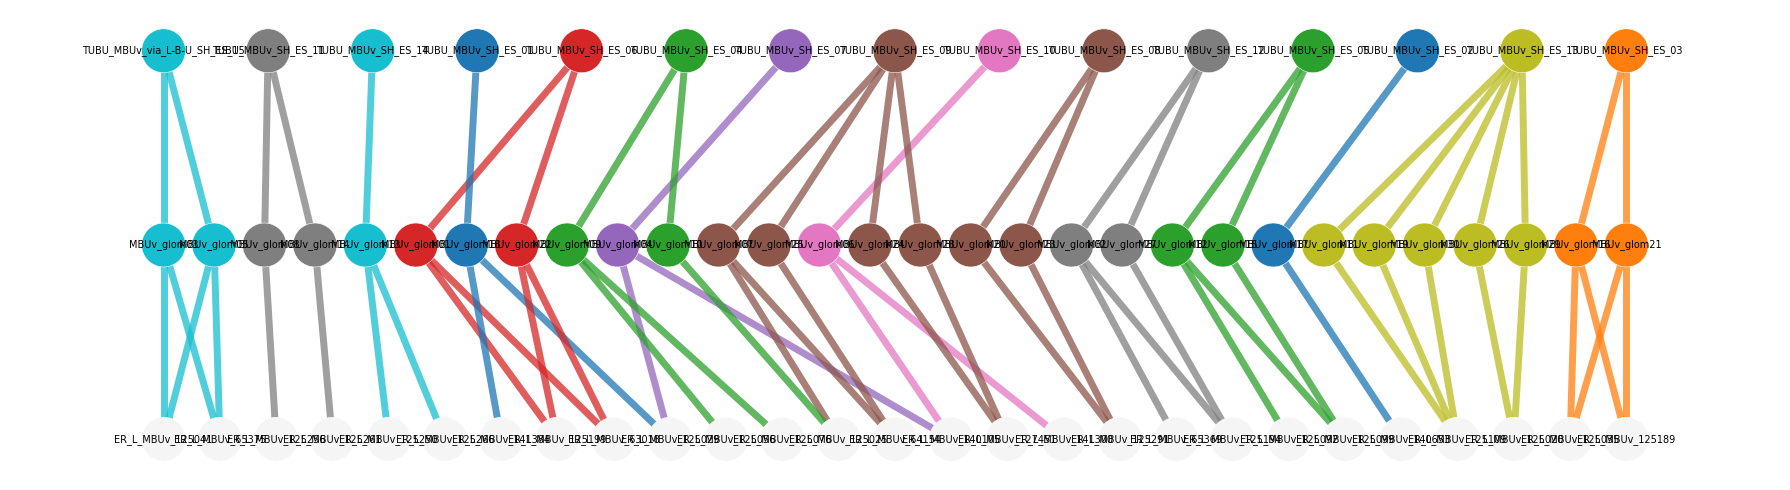

In [204]:
# plot
G = build_tubu_glom_er_graph(glom_dict, use="name")
draw_graph_colored_optimized(G, filename='MBUv', figsize=(18,5), labels=True)

In [202]:
df_tubu, df_er, summary, tubu_to_er_glomcount = quantify_tubu_er(G)

summary

# divergence_mean_ERs_per_TUBU -> on average each TUBU innervate x glomeruli
# n_multi_input_gloms -> number of glomeruli that get input from more than one TUBU

{'n_TUBU': 15,
 'n_GLOM': 30,
 'n_ER': 27,
 'n_effective_TUBU_to_ER_pairs': 30,
 'divergence_mean_ERs_per_TUBU': 2.0,
 'convergence_mean_TUBUs_per_ER': 1.1111111111111112,
 'n_multi_input_gloms': 0}

In [133]:
df_er

,ER,gloms_in,TUBU_in_unique,mean_TUBUs_per_glom,max_TUBUs_per_glom
6,ER_L_MBUv_140105,2,2,1.0,1
7,ER_L_MBUv_125029,2,2,1.0,1
9,ER_L_MBUv_125025,2,2,1.0,1
14,ER_L_MBUv_125109,3,1,1.0,1
0,ER_L_MBUv_63018,2,1,1.0,1
1,ER_L_MBUv_125199,2,1,1.0,1
2,ER_L_MBUv_125194,2,1,1.0,1
4,ER_L_MBUv_65375,2,1,1.0,1
5,ER_L_MBUv_125041,2,1,1.0,1
10,ER_L_MBUv_64154,2,1,1.0,1


In [134]:
def plot_divergence_histogram(df_tubu, bins=None, figsize=(4, 3)):
    data = df_tubu["ER_out_unique"].values

    if bins is None:
        bins = np.arange(data.min(), data.max() + 2) - 0.5  # integer-centered bins

    plt.figure(figsize=figsize)
    plt.hist(data, bins=bins)

    plt.xlabel("Number of ER neurons per TUBU")
    plt.ylabel("Number of TUBU neurons")
    plt.title("TUBU → ER divergence")

    plt.xticks(np.unique(data))
    plt.tight_layout()
    plt.show()


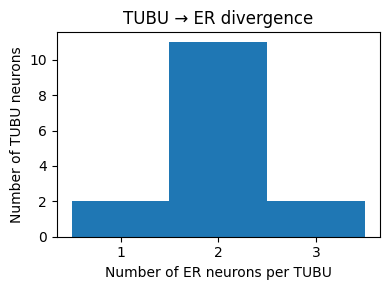

In [135]:
plot_divergence_histogram(df_tubu)


In [136]:
def plot_convergence_histogram(df_er, bins=None, figsize=(4, 3)):
    data = df_er["TUBU_in_unique"].values

    if bins is None:
        bins = np.arange(data.min(), data.max() + 2) - 0.5

    plt.figure(figsize=figsize)
    plt.hist(data, bins=bins)

    plt.xlabel("Number of TUBU neurons per ER")
    plt.ylabel("Number of ER neurons")
    plt.title("ER ← TUBU convergence")

    plt.xticks(np.unique(data))
    plt.tight_layout()
    plt.show()


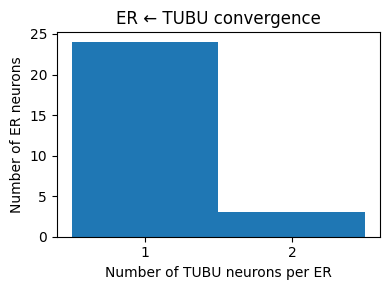

In [137]:
plot_convergence_histogram(df_er)


In [90]:
glom_ann = {}

for k, v in glom_dict.items():
    names = v["name"].astype(str)
    tubu = names.str.startswith("TUBU").sum()
    er   = names.str.startswith("ER").sum()
    
    glom_skid = (v.loc[v["name"].str.contains("glom"), "skeleton_ids"].iloc[0][0])
    
    motif_annot = f"motif:{tubu}TUBU_to_{er}ER"

    glom_ann[glom_skid] = motif_annot


glom_ann

{33818: 'motif:1TUBU_to_2ER',
 194696: 'motif:1TUBU_to_2ER',
 146538: 'motif:1TUBU_to_2ER',
 33859: 'motif:1TUBU_to_2ER',
 33936: 'motif:1TUBU_to_2ER',
 33991: 'motif:1TUBU_to_2ER',
 146682: 'motif:1TUBU_to_2ER',
 33822: 'motif:1TUBU_to_1ER',
 33834: 'motif:1TUBU_to_2ER',
 33931: 'motif:1TUBU_to_1ER',
 33969: 'motif:1TUBU_to_1ER',
 34031: 'motif:1TUBU_to_2ER',
 125394: 'motif:1TUBU_to_2ER',
 125401: 'motif:1TUBU_to_1ER',
 33940: 'motif:1TUBU_to_1ER',
 33946: 'motif:1TUBU_to_2ER',
 149391: 'motif:1TUBU_to_1ER',
 150116: 'motif:1TUBU_to_2ER',
 150141: 'motif:1TUBU_to_1ER',
 150634: 'motif:1TUBU_to_1ER',
 150909: 'motif:1TUBU_to_2ER',
 153697: 'motif:1TUBU_to_2ER',
 153715: 'motif:1TUBU_to_1ER',
 149330: 'motif:1TUBU_to_1ER',
 149335: 'motif:1TUBU_to_1ER',
 149340: 'motif:1TUBU_to_1ER',
 149350: 'motif:1TUBU_to_1ER',
 149366: 'motif:1TUBU_to_1ER',
 149371: 'motif:1TUBU_to_1ER',
 150145: 'motif:1TUBU_to_1ER'}

In [91]:
# # to add to CATMAID
# for k, v in glom_ann.items(): # k = skid, v = annotation to add
#     pymaid.add_annotations(k, v, remote_instance=megalopta_client) 

### left side MBUd (no right side TUBU in sweat bee)

In [183]:
mbud_glomlist = pymaid.find_neurons(names="MBUd_L_glom", partial_match=True, remote_instance=megalopta_client)
mbud_glomlist

Make nrn:   0%|          | 0/49 [00:00<?, ?it/s]

INFO  : Found 49 neurons matching the search parameters (pymaid)


,type,name,skeleton_id,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units
0,CatmaidNeuron,MBUd_L_glom_30,33923,NA,NA,NA,NA,NA,NA,1 nanometer
1,CatmaidNeuron,MBUd_L_glom_11,33927,NA,NA,NA,NA,NA,NA,1 nanometer
...,...,...,...,...,...,...,...,...,...,...
47,CatmaidNeuron,MBUd_L_glom_26,125565,NA,NA,NA,NA,NA,NA,1 nanometer
48,CatmaidNeuron,MBUd_L_glom_19,33919,NA,NA,NA,NA,NA,NA,1 nanometer


In [184]:
glom_list = []

for n in mbud_glomlist:
    for annot in n.annotations:
        if annot.startswith("MBUd_glom"):
            glom_list.append(annot)

print(len(glom_list))

glom_list = np.sort(glom_list)

# make a dict with each key as a glom and each value a df of the neurons that innervate that glom
glom_dict = {}

for glom in glom_list:
    g = pymaid.get_annotated(glom, remote_instance=megalopta_client)
    glom_dict[glom] = g

glom_dict

49


INFO  : Searching for: MBUd_glom01 (pymaid)
INFO  : Searching for: MBUd_glom02 (pymaid)
INFO  : Searching for: MBUd_glom03 (pymaid)
INFO  : Searching for: MBUd_glom04 (pymaid)
INFO  : Searching for: MBUd_glom05 (pymaid)
INFO  : Searching for: MBUd_glom06 (pymaid)
INFO  : Searching for: MBUd_glom07 (pymaid)
INFO  : Searching for: MBUd_glom08 (pymaid)
INFO  : Searching for: MBUd_glom09 (pymaid)
INFO  : Searching for: MBUd_glom10 (pymaid)
INFO  : Searching for: MBUd_glom11 (pymaid)
INFO  : Searching for: MBUd_glom12 (pymaid)
INFO  : Searching for: MBUd_glom13 (pymaid)
INFO  : Searching for: MBUd_glom15 (pymaid)
INFO  : Searching for: MBUd_glom17 (pymaid)
INFO  : Searching for: MBUd_glom18 (pymaid)
INFO  : Searching for: MBUd_glom19 (pymaid)
INFO  : Searching for: MBUd_glom20 (pymaid)
INFO  : Searching for: MBUd_glom21 (pymaid)
INFO  : Searching for: MBUd_glom22 (pymaid)
INFO  : Searching for: MBUd_glom23 (pymaid)
INFO  : Searching for: MBUd_glom24 (pymaid)
INFO  : Searching for: MBUd_glom

{'MBUd_glom01':        id                    name    type skeleton_ids
 0  129327        ER_L_MBUd_129326  neuron     [129326]
 1  129545          MBUd_L_glom_01  neuron     [129544]
 2  151603  TUBU_MBUd_SH_01_viaLBU  neuron     [151602],
 'MBUd_glom02':        id                name    type skeleton_ids
 0  129539    ER_L_MBUd_129538  neuron     [129538]
 1  149967  TUBU_MBUd_SH_ES_02  neuron     [149966]
 2  150100      MBUd_L_glom_02  neuron     [150099],
 'MBUd_glom03':        id                name    type skeleton_ids
 0  134107    ER_L_MBUd_134106  neuron     [134106]
 1  146652      MBUd_L_glom_03  neuron     [146651]
 2  149977  TUBU_MBUd_SH_ES_38  neuron     [149976],
 'MBUd_glom04':        id              name    type skeleton_ids
 0  135362  ER_L_MBUd_135361  neuron     [135361]
 1  150618    MBUd_L_glom_04  neuron     [150617]
 2  151591   TUBU_MBUd_SH_04  neuron     [151590],
 'MBUd_glom05':        id                name    type skeleton_ids
 0   33847      MBUd_L_glom_0

Saved figure → ./plots\MBUd.pdf


C:\Users\Marcel\AppData\Local\Temp\ipykernel_22056\1565889337.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(cmap_name, len(tubus))


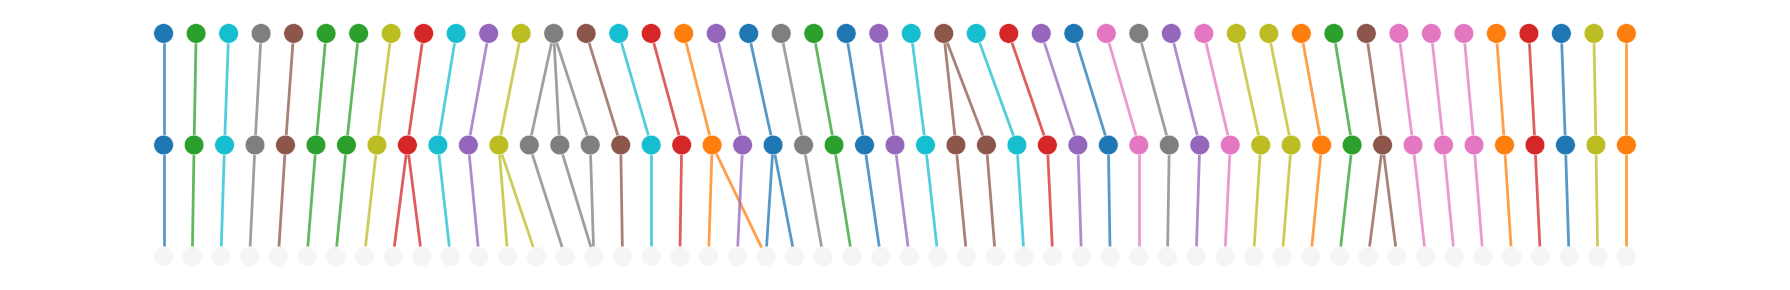

In [196]:
# plot
G = build_tubu_glom_er_graph(glom_dict, use="name")
draw_graph_colored_optimized(G, edge_width=2.0, filename='MBUd', node_size=200, figsize=(18, 3))

In [167]:
df_tubu, df_er, summary, tubu_to_er_glomcount = quantify_tubu_er(G)

summary

{'n_TUBU': 46,
 'n_GLOM': 49,
 'n_ER': 52,
 'n_effective_TUBU_to_ER_pairs': 53,
 'divergence_mean_ERs_per_TUBU': 1.1521739130434783,
 'convergence_mean_TUBUs_per_ER': 1.0192307692307692,
 'n_multi_input_gloms': 0}

# Eciton

In [ ]:
eciton = pymaid.find_neurons(names="", partial_match=True, remote_instance=eciton_client)
mbud_glomlist

In [ ]:
glom_list = []

for n in mbud_glomlist:
    for annot in n.annotations:
        if annot.startswith("MBUd_glom"):
            glom_list.append(annot)

print(len(glom_list))

glom_list = np.sort(glom_list)

# make a dict with each key as a glom and each value a df of the neurons that innervate that glom
glom_dict = {}

for glom in glom_list:
    g = pymaid.get_annotated(glom, remote_instance=megalopta_client)
    glom_dict[glom] = g

glom_dict

In [ ]:
# plot
G = build_tubu_glom_er_graph(glom_dict, use="name")
draw_graph_colored_optimized(G, edge_width=2.0, filename='MBUd', node_size=200, figsize=(18, 3))